In [38]:
import tensorflow as tf
gpu = tf.config.list_physical_devices("GPU")
print(gpu)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [40]:
import numpy as np
np.__version__

'1.23.5'

In [41]:
import cv2 as cv
cv.__version__

'4.6.0'

In [42]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense

# ! pip install matplotlib

In [44]:
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images,test_labels) = mnist.load_data()

In [45]:
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [46]:
num = train_images[0]

for i in range(28):
    for j in range(28):
        print("{:4d}".format(num[i][j]),end=" ")
    print()

   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
   0    0    0    0    0    0    0    0    0    0    0    0    3   18   18   18  126  136  175   26  166  255  247  127    0    0    0    0 
   0    0    0    0    0    0    0    0   30   36   94  154  170  253  253  253  253  253  225  172  253  242  195   64    0    0    0    0 
   0    0    

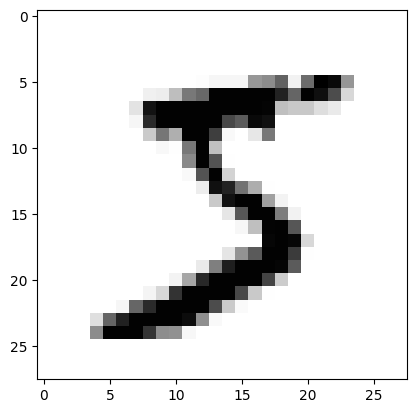

In [47]:
plt.imshow(train_images[0],cmap='Greys')

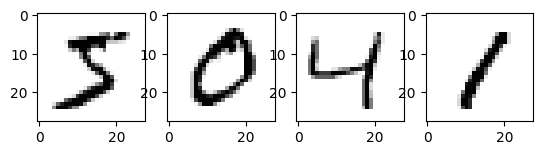

In [48]:
fig = plt.figure()
ax1 = fig.add_subplot(1,4,1)
ax2 = fig.add_subplot(1,4,2)
ax3 = fig.add_subplot(1,4,3)
ax4 = fig.add_subplot(1,4,4)

ax1.imshow(train_images[0],cmap='Greys')
ax2.imshow(train_images[1],cmap='Greys')
ax3.imshow(train_images[2],cmap='Greys')
ax4.imshow(train_images[3],cmap='Greys')

In [49]:
# 1단계 : 데이터 전처리

train_images,test_images = train_images/255, test_images/255

In [50]:
# 2단계 : 신경망 모델 만들기

model = keras.Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(60, activation='relu'))
model.add(Dense(10, activation='sigmoid'))

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_4 (Dense)             (None, 60)                47100     
                                                                 
 dense_5 (Dense)             (None, 10)                610       
                                                                 
Total params: 47,710
Trainable params: 47,710
Non-trainable params: 0
_________________________________________________________________


In [51]:
# 3단계 : 신경망 모델의 활성화 함수, 최적화 함수, 측정 방법

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [52]:
# 4단계 : 모델 학습

model.fit(train_images,train_labels,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3065 - accuracy: 0.9132
Epoch 2/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1498 - accuracy: 0.9571
Epoch 3/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1089 - accuracy: 0.9682
Epoch 4/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0856 - accuracy: 0.9742
Epoch 5/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0710 - accuracy: 0.9785


In [53]:
# 5단계 : 모델의 정확도 알아보기

test_loss,test_acc = model.evaluate(test_images,test_labels)
print('test acc :', test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.0821 - accuracy: 0.9751
test acc : 0.9750999808311462


Epoch 1/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0584 - accuracy: 0.9819
Epoch 2/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0504 - accuracy: 0.9844
Epoch 3/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0449 - accuracy: 0.9858
Epoch 4/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0385 - accuracy: 0.9879
Epoch 5/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0330 - accuracy: 0.9900


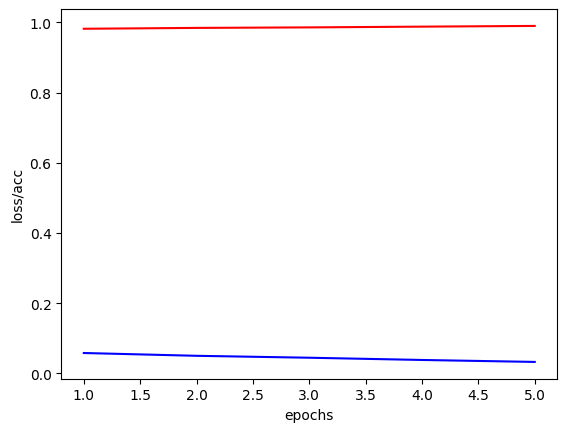

In [54]:
# 정확도 및 손실 변화 그래프

history = model.fit(train_images,train_labels,epochs=5)
loss = history.history['loss']
acc = history.history['accuracy']
epochs = range(1,len(loss)+1)

plt.plot(epochs,loss,'b',label='Training Loss')
plt.plot(epochs,acc,'r',label='Accuracy')
plt.xlabel('epochs')
plt.ylabel('loss/acc')
plt.show()

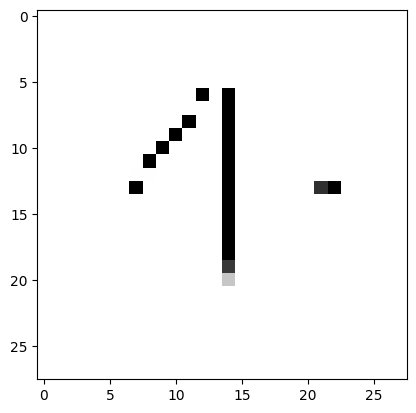

1/1 [==============================] - 0s 32ms/step
[[0.02115773 0.7815858  0.1248063  0.26577583 0.4725908  0.10970355
  0.02926678 0.4464427  0.19401802 0.6547815 ]]
예측된 숫자 = 1


In [55]:
image = cv.imread('test/num4.png',cv.IMREAD_GRAYSCALE)
image = cv.resize(image,(28,28))
image = image.astype('float32')
image = image.reshape(1,784)
image = 255-image
image = image/255

plt.imshow(image.reshape(28,28),cmap='Grays')
plt.show()

pred = model.predict(image.reshape(1,28,28))
print(pred)
print('예측된 숫자 =',pred.argmax())